# 05. Сравнение со StatsBomb и анализ ошибок

Насколько собственная модель близка к профессиональной оценке
и где именно расходятся прогнозы.

In [1]:
import json
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

In [2]:
from xg_context.config import PROCESSED_DATA_DIR, TABLES_DIR
from xg_context.visualization import apply_style, plot_calibration, plot_error_analysis

apply_style()
predictions = pd.read_parquet(PROCESSED_DATA_DIR / 'test_predictions.parquet')
metrics = pd.read_csv(TABLES_DIR / 'model_metrics.csv')
predictions.shape

(5639, 22)

## Итоговая таблица

`statsbomb_xg` оценён на **тех же тестовых ударах** и теми же метриками.

In [3]:
metrics[['model', 'feature_set', 'test_log_loss', 'test_brier', 'test_roc_auc', 'test_pr_auc']].round(5)

,model,feature_set,test_log_loss,test_brier,test_roc_auc,test_pr_auc
0,statsbomb_xg (benchmark),—,0.24042,0.06824,0.83458,0.44219
1,Логистическая регрессия,geometry_shot_flags_defensive,0.24271,0.06922,0.83004,0.42475
2,Логистическая регрессия,geometry_shot_flags_defensive_no_visible,0.24315,0.06941,0.82995,0.42223
3,Случайный лес,geometry_shot_flags_defensive,0.24325,0.06945,0.82964,0.42195
4,Случайный лес,geometry_shot_flags_defensive_no_visible,0.24366,0.06968,0.82954,0.41684
5,Градиентный бустинг,geometry_shot_flags,0.25234,0.07172,0.80827,0.38163
6,Случайный лес,geometry_shot_flags,0.25400,0.07223,0.80494,0.37517
7,Логистическая регрессия,geometry_shot_flags,0.25456,0.07209,0.80219,0.37969
8,Логистическая регрессия,geometry_shot,0.25630,0.07268,0.80068,0.36806
9,Случайный лес,geometry_shot,0.25783,0.07356,0.80174,0.35732


Сравнение не полностью равное: StatsBomb обучает модель на закрытых
данных большего объёма. Проект не обязан её превосходить.

In [4]:
bootstrap = pd.read_csv(TABLES_DIR / 'bootstrap.csv')
bootstrap[bootstrap['сравнение'].str.contains('statsbomb')].T

,7
сравнение,Лучшая модель против statsbomb_xg
n_matches,224
n_shots,5639
n_bootstrap,1000
confidence_level,0.95
delta_log_loss,0.002831
delta_log_loss_ci_low,-0.000919
delta_log_loss_ci_high,0.006546
delta_log_loss_significant,False
delta_brier,0.001203


## Калибровка

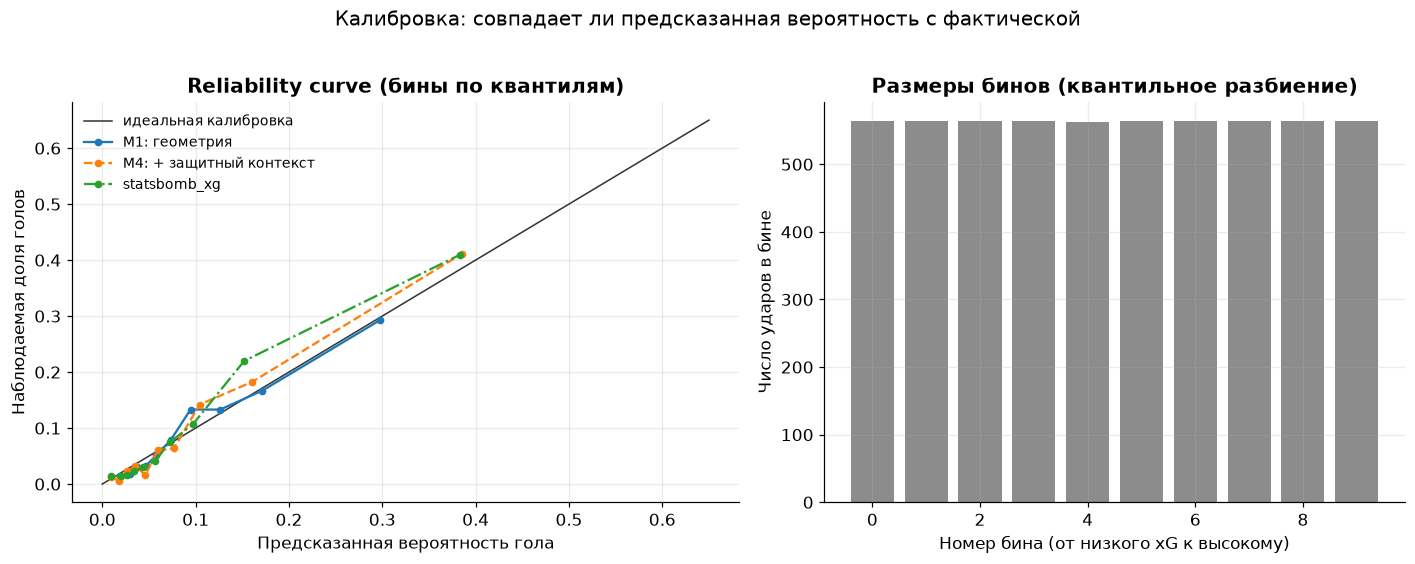

In [5]:
curves = {
    'M1: геометрия': 'calibration_logistic_geometry.csv',
    'M4: + защитный контекст': 'calibration_logistic_geometry_shot_flags_defensive.csv',
    'statsbomb_xg': 'calibration_statsbomb_xg.csv',
}
tables = {label: pd.read_csv(TABLES_DIR / name) for label, name in curves.items()}
plot_calibration(tables);

In [6]:
pd.read_csv(TABLES_DIR / 'calibration_summary.csv').round(5)

,key,модель,набор признаков,ECE,средний прогноз,фактическая доля голов
0,random_forest@geometry,Случайный лес,geometry,0.00621,0.09454,0.09487
1,gradient_boosting@geometry_shot_flags,Градиентный бустинг,geometry_shot_flags,0.00642,0.09266,0.09487
2,decision_tree@geometry_shot_flags,Дерево решений,geometry_shot_flags,0.00669,0.09292,0.09487
3,random_forest@geometry_shot_flags,Случайный лес,geometry_shot_flags,0.00916,0.09213,0.09487
4,logistic@geometry_shot,Логистическая регрессия,geometry_shot,0.01011,0.09312,0.09487
5,logistic@geometry,Логистическая регрессия,geometry,0.01036,0.09523,0.09487
6,logistic@geometry_shot_flags,Логистическая регрессия,geometry_shot_flags,0.01111,0.09227,0.09487
7,random_forest@geometry_shot_flags_defensive_no...,Случайный лес,geometry_shot_flags_defensive_no_visible,0.01150,0.09375,0.09487
8,random_forest@geometry_shot,Случайный лес,geometry_shot,0.01284,0.09310,0.09487
9,random_forest@geometry_shot_flags_defensive,Случайный лес,geometry_shot_flags_defensive,0.01331,0.09359,0.09487


## Метрики по лигам

In [7]:
from xg_context.visualization import plot_league_skill

skill = pd.read_csv(TABLES_DIR / 'league_skill.csv')
skill[['лига', 'модель', 'n', 'доля голов', 'log loss', 'skill log loss', 'BSS', 'ROC-AUC', 'ECE']].round(4)

,лига,модель,n,доля голов,log loss,skill log loss,BSS,ROC-AUC,ECE
0,La Liga,Логистическая + защитный контекст,1361,0.1065,0.2600,0.2351,0.1913,0.8460,0.0232
1,La Liga,Логистическая без контекста,1361,0.1065,0.2782,0.1817,0.1436,0.8091,0.0193
2,La Liga,Случайный лес + защитный контекст,1361,0.1065,0.2573,0.2432,0.2032,0.8467,0.0239
3,La Liga,statsbomb_xg,1361,0.1065,0.2543,0.2518,0.2148,0.8561,0.0285
4,Ligue 1,Логистическая + защитный контекст,1314,0.0974,0.2563,0.1975,0.1775,0.8033,0.0112
5,Ligue 1,Логистическая без контекста,1314,0.0974,0.2596,0.1872,0.1690,0.7909,0.0195
6,Ligue 1,Случайный лес + защитный контекст,1314,0.0974,0.2533,0.2070,0.1792,0.8166,0.0191
7,Ligue 1,statsbomb_xg,1314,0.0974,0.2547,0.2027,0.1841,0.8081,0.0185
8,Premier League,Логистическая + защитный контекст,1478,0.0920,0.2421,0.2120,0.1887,0.8108,0.0108
9,Premier League,Логистическая без контекста,1478,0.0920,0.2525,0.1783,0.1589,0.7844,0.0057


Сырой log loss между лигами сравнивать нельзя: он механически ниже там,
где реже забивают. Поэтому ниже — относительные метрики: качество модели
по отношению к `DummyClassifier`, оценённому на тех же строках.

## Анализ ошибок по подгруппам

In [8]:
subgroups = pd.read_csv(TABLES_DIR / 'error_analysis.csv')
subgroups[['подгруппа', 'n', 'доля_голов', 'log_loss_без_контекста', 'log_loss_с_контекстом', 'улучшение']].round(5)

,подгруппа,n,доля_голов,log_loss_без_контекста,log_loss_с_контекстом,улучшение
0,Удары головой,958,0.11169,0.30465,0.29934,0.00531
1,Удары ногой,4663,0.09050,0.24338,0.23018,0.01320
2,Острый угол (< 15°),1439,0.01529,0.08300,0.08020,0.00280
3,Центральная позиция (> 30°),1426,0.20898,0.43125,0.41750,0.01375
4,Ближние удары (< 12 ярдов),1319,0.21304,0.43916,0.42397,0.01519
5,Средняя дистанция (12–20),1648,0.10619,0.31040,0.29219,0.01821
6,Дальние удары (> 20 ярдов),2672,0.02957,0.12900,0.12273,0.00627
7,Open play,5375,0.09674,0.25622,0.24406,0.01216
8,Стандарты,264,0.05682,0.22092,0.21532,0.00560
9,Открытый момент (0 в конусе),2694,0.14105,0.33151,0.31647,0.01504


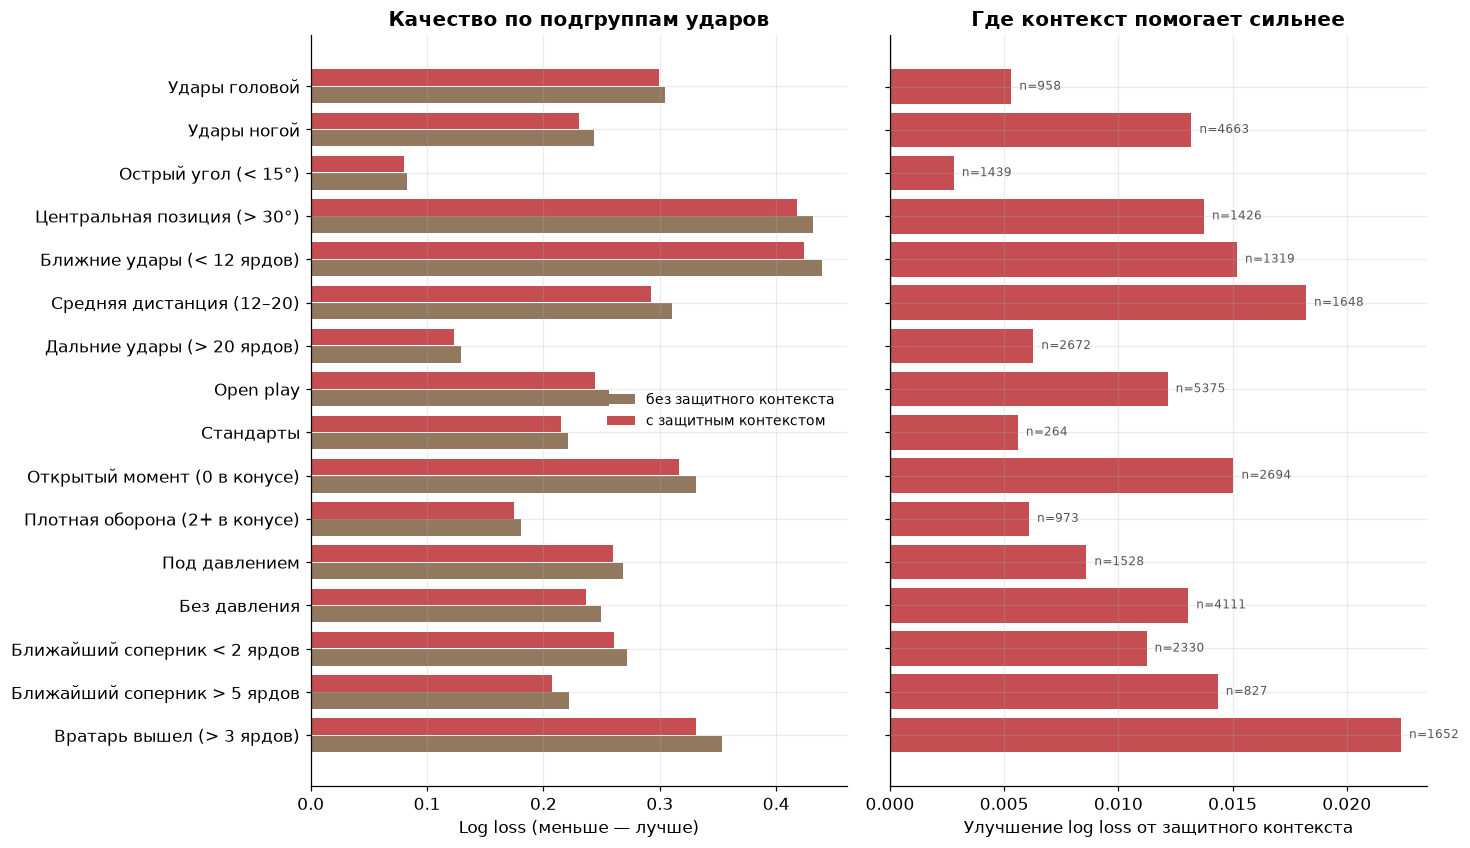

In [9]:
plot_error_analysis(subgroups);

Защитный контекст помогает сильнее всего там, где он и должен:
когда вратарь вышел из ворот, на средней дистанции и в моментах,
которые геометрически выглядят опасными. На дальних ударах и при
очень острых углах прирост мал — там исход и так почти предопределён.

## Примеры ударов

In [10]:
examples = pd.read_csv(TABLES_DIR / 'example_shots.csv')
examples[['причина', 'competition_name', 'is_goal', 'shot_distance', 'opponents_in_shot_cone', 'nearest_opponent_distance', 'p_logistic_no_defense', 'p_logistic_defense', 'statsbomb_xg']].round(3)

,причина,competition_name,is_goal,shot_distance,opponents_in_shot_cone,nearest_opponent_distance,p_logistic_no_defense,p_logistic_defense,statsbomb_xg
0,контекст сильно повысил прогноз,La Liga,1,13.087,0.0,4.826,0.232,0.822,0.751
1,контекст сильно повысил прогноз,La Liga,0,18.363,0.0,8.668,0.110,0.668,0.378
2,контекст сильно повысил прогноз,Premier League,1,15.028,0.0,2.746,0.437,0.938,0.983
3,контекст сильно понизил прогноз,Serie A,0,39.602,0.0,16.787,0.526,0.097,0.000
4,контекст сильно понизил прогноз,Ligue 1,0,7.926,1.0,1.082,0.512,0.270,0.089
5,контекст сильно понизил прогноз,La Liga,0,4.230,2.0,0.943,0.518,0.281,0.210
6,мы выше statsbomb_xg,La Liga,0,8.501,0.0,6.329,0.721,0.747,0.317
7,мы выше statsbomb_xg,Ligue 1,0,16.056,0.0,1.030,0.081,0.484,0.166
8,мы выше statsbomb_xg,Premier League,0,5.707,0.0,3.489,0.599,0.521,0.214
9,мы ниже statsbomb_xg,Serie A,0,10.197,0.0,2.247,0.295,0.325,0.748


Отдельного внимания заслуживают удары с флагом `one_on_one` из очень
острых позиций: линейная модель без защитного контекста завышает по ним
вероятность, а пространственные признаки возвращают прогноз к разумным
значениям.

Полные выводы и ограничения — в [`reports/results.md`](../reports/results.md).

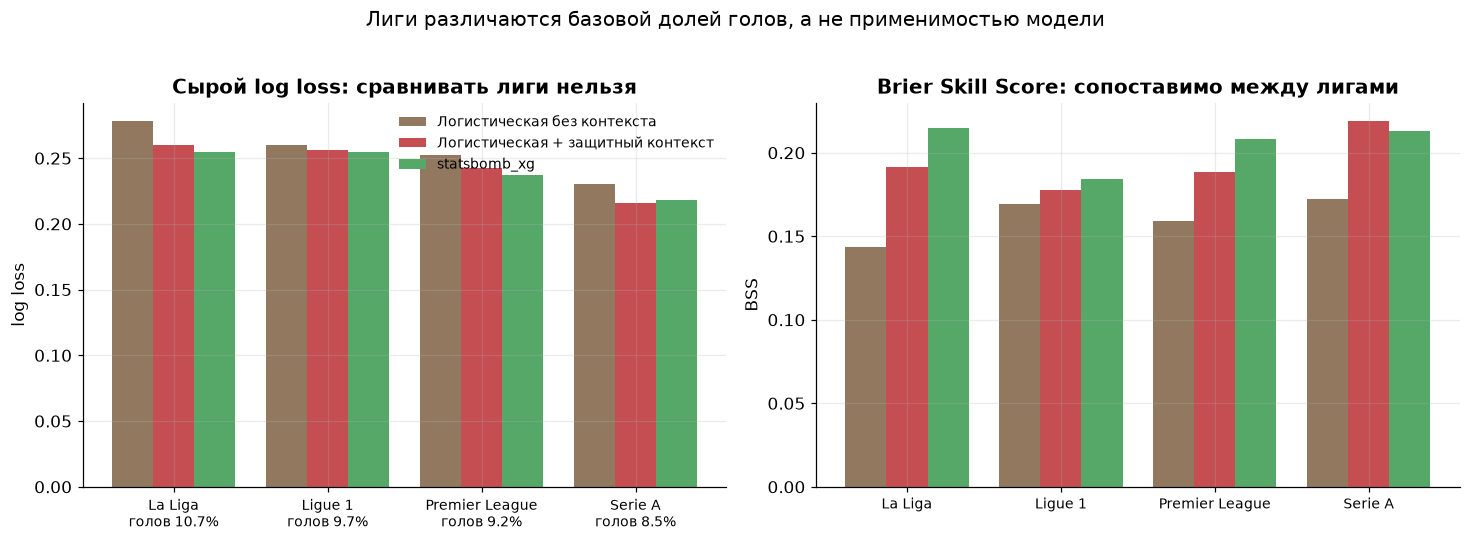

In [11]:
plot_league_skill(skill);

Размах Brier Skill Score между лигами мал, то есть модель работает
в четырёх лигах сопоставимо. Защитный контекст помогает во всех четырёх,
но в Ligue 1 заметно слабее остальных.